In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [ ]:
df = pd.read_csv("D:\Projects\lpg_flow_prediction\data\df_clean.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

In [ ]:
print("=" * 60)
print("WEATHERING TEMPERATURE ANALYSIS")
print("=" * 60)

print("\nStatistics:")
print(df["Wthr"].describe())

print("\nUnique Values:")
print(sorted(df["Wthr"].dropna().unique()))

print("\nNumber of Unique Values:")
print(df["Wthr"].nunique())

print("\nMissing Values:")
print(df["Wthr"].isna().sum())

print("\nValue Counts:")
print(df["Wthr"].value_counts().sort_index())

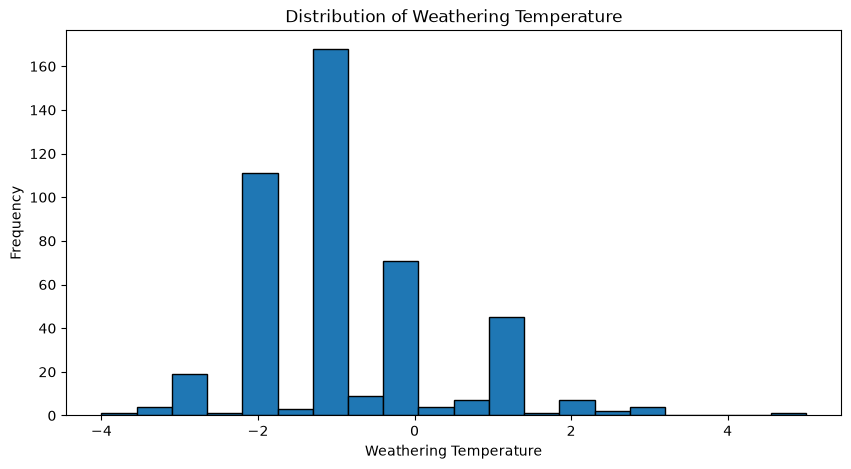

In [5]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["Wthr"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.xlabel("Weathering Temperature")
plt.ylabel("Frequency")
plt.title("Distribution of Weathering Temperature")

plt.show()

In [6]:
# Explore possible classification thresholds

thresholds = [-2, -1, 0, 1, 2]

for threshold in thresholds:
    
    good = (df["Wthr"] <= threshold).sum()
    bad = (df["Wthr"] > threshold).sum()
    
    print(f"\nThreshold: Wthr <= {threshold}")
    print(f"Class 0: {good}")
    print(f"Class 1: {bad}")
    print(f"Ratio  : {good / len(df):.2%} / {bad / len(df):.2%}")


Threshold: Wthr <= -2
Class 0: 136
Class 1: 322
Ratio  : 29.69% / 70.31%

Threshold: Wthr <= -1
Class 0: 307
Class 1: 151
Ratio  : 67.03% / 32.97%

Threshold: Wthr <= 0
Class 0: 387
Class 1: 71
Ratio  : 84.50% / 15.50%

Threshold: Wthr <= 1
Class 0: 439
Class 1: 19
Ratio  : 95.85% / 4.15%

Threshold: Wthr <= 2
Class 0: 451
Class 1: 7
Ratio  : 98.47% / 1.53%


In [7]:
def quality_band(wthr):
    distance = abs(wthr - 2)

    if distance <= 0.5:
        return "Near Target"
    elif distance <= 1.0:
        return "Moderately Close"
    elif distance <= 2.0:
        return "Far"
    else:
        return "Very Far"

df["Quality_Band"] = df["Wthr"].apply(quality_band)

print(df["Quality_Band"].value_counts())

print("\nPercentage:")
print(df["Quality_Band"].value_counts(normalize=True) * 100)

Quality_Band
Very Far            319
Far                  80
Moderately Close     49
Near Target          10
Name: count, dtype: int64

Percentage:
Quality_Band
Very Far            69.650655
Far                 17.467249
Moderately Close    10.698690
Near Target          2.183406
Name: proportion, dtype: float64


In [8]:
TARGET_WTHR = 2

df["Distance_From_Target"] = abs(df["Wthr"] - TARGET_WTHR)

df["Wthr_Class"] = np.where(
    df["Distance_From_Target"] <= 2,
    1,  # Closer to target
    0   # Far from target
)

print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

print(df["Wthr_Class"].value_counts())

print("\nPercentage:")
print(df["Wthr_Class"].value_counts(normalize=True) * 100)

CLASS DISTRIBUTION
Wthr_Class
0    319
1    139
Name: count, dtype: int64

Percentage:
Wthr_Class
0    69.650655
1    30.349345
Name: proportion, dtype: float64


In [12]:
# Target
y = df["Wthr_Class"]

# Features
X = df.drop(
    columns=[
        "DATE",
        "Wthr",
        "Wthr_Class",
        "Distance_From_Target",
        "Quality_Band"
    ],
    errors="ignore"
)

print("=" * 60)
print("FEATURE SET")
print("=" * 60)

print("Number of Features:", X.shape[1])
print("Number of Samples :", X.shape[0])

print("\nFeatures:")
print(X.columns.tolist())

print("\nData Types:")
print(X.dtypes)

FEATURE SET
Number of Features: 22
Number of Samples : 458

Features:
['Stabilizer Feed T', 'Stabilizer Feed Flow', 'Stabilizer Top P', 'Stabilizer Reflux Drum T', 'Stabilized Naphtha Flow', 'Stabilizer Reflux Flow', 'HGO CR Flow', 'HGO CR to reboiler Flow', 'LPG Flow', 'Stabilizer Top T', 'Stabilizer Top T.1', 'Stabilizer Bottom T', 'Stabiliser bottom level', 'Stabilier bottom pressure', 'Stab. 3rd Tray', 'Stab. 3rd Tray.1', 'HGO CR Reboiler Inlet Temp( TI-1914)', 'Bottom Reboiler Naphtha Inlet Temp( TI-1907)', 'Bot. Naphtha Reboiler Outlet Temp(TI-1908 & TI-1909)', 'Bot. Naphtha Reboiler Outlet Temp(TI-1908 & TI-1909).1', 'Off Spec LPG flow (tag Faulty)', 'Off Spec LPG from CRU inlet pressure']

Data Types:
Stabilizer Feed T                                         float64
Stabilizer Feed Flow                                      float64
Stabilizer Top P                                          float64
Stabilizer Reflux Drum T                                  float64
Stabilized Naphth

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

TRAIN / TEST SPLIT
Training Samples: 366
Testing Samples : 92

Training Class Distribution:
Wthr_Class
0    255
1    111
Name: count, dtype: int64

Testing Class Distribution:
Wthr_Class
0    64
1    28
Name: count, dtype: int64


In [14]:
print("=" * 60)
print("EXPERIMENT 1")
print("Random Forest Classifier - Baseline")
print("=" * 60)

model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print("\nPerformance")
print("-" * 35)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report")
print("-" * 35)

print(classification_report(
    y_test,
    pred,
    target_names=["Far From Target", "Closer To Target"]
))

print("\nConfusion Matrix")
print("-" * 35)

print(confusion_matrix(y_test, pred))

EXPERIMENT 1
Random Forest Classifier - Baseline

Performance
-----------------------------------
Accuracy  : 0.7283
Precision : 0.6154
Recall    : 0.2857
F1 Score  : 0.3902

Classification Report
-----------------------------------
                  precision    recall  f1-score   support

 Far From Target       0.75      0.92      0.83        64
Closer To Target       0.62      0.29      0.39        28

        accuracy                           0.73        92
       macro avg       0.68      0.60      0.61        92
    weighted avg       0.71      0.73      0.69        92


Confusion Matrix
-----------------------------------
[[59  5]
 [20  8]]


In [15]:
print("=" * 60)
print("EXPERIMENT 2")
print("Random Forest - Balanced Class Weights")
print("=" * 60)

model_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

model_balanced.fit(X_train, y_train)

pred_balanced = model_balanced.predict(X_test)

accuracy = accuracy_score(y_test, pred_balanced)
precision = precision_score(y_test, pred_balanced)
recall = recall_score(y_test, pred_balanced)
f1 = f1_score(y_test, pred_balanced)

print("\nPerformance")
print("-" * 35)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report")
print("-" * 35)

print(classification_report(
    y_test,
    pred_balanced,
    target_names=["Far From Target", "Closer To Target"]
))

print("\nConfusion Matrix")
print("-" * 35)

print(confusion_matrix(y_test, pred_balanced))

EXPERIMENT 2
Random Forest - Balanced Class Weights

Performance
-----------------------------------
Accuracy  : 0.6630
Precision : 0.4483
Recall    : 0.4643
F1 Score  : 0.4561

Classification Report
-----------------------------------
                  precision    recall  f1-score   support

 Far From Target       0.76      0.75      0.76        64
Closer To Target       0.45      0.46      0.46        28

        accuracy                           0.66        92
       macro avg       0.61      0.61      0.61        92
    weighted avg       0.67      0.66      0.66        92


Confusion Matrix
-----------------------------------
[[48 16]
 [15 13]]


In [16]:
print("=" * 60)
print("EXPERIMENT 3")
print("Feature Importance Analysis")
print("=" * 60)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_balanced.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.to_string(index=False))

EXPERIMENT 3
Feature Importance Analysis
                                               Feature  Importance
                                              LPG Flow    0.070497
                                        Stab. 3rd Tray    0.057443
                               Stabiliser bottom level    0.056637
                                Stabilizer Reflux Flow    0.055724
                                      Stab. 3rd Tray.1    0.054220
                                           HGO CR Flow    0.051915
                                     Stabilizer Feed T    0.051537
                               Stabilized Naphtha Flow    0.048304
                               HGO CR to reboiler Flow    0.047092
          Bottom Reboiler Naphtha Inlet Temp( TI-1907)    0.044618
                                    Stabilizer Top T.1    0.044616
                  HGO CR Reboiler Inlet Temp( TI-1914)    0.044528
                                      Stabilizer Top T    0.044360
                     

In [17]:
print("=" * 70)
print("EXPERIMENT 4")
print("Classification Probability Threshold Analysis")
print("=" * 70)

# Probability that sample belongs to Class 1
# Class 1 = Closer To Target
probabilities = model_balanced.predict_proba(X_test)[:, 1]

thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

results = []

for threshold in thresholds:

    pred_threshold = (
        probabilities >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        pred_threshold
    )

    precision = precision_score(
        y_test,
        pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        pred_threshold,
        zero_division=0
    )

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })


threshold_results = pd.DataFrame(results)

print(threshold_results.to_string(index=False))

EXPERIMENT 4
Classification Probability Threshold Analysis
 Threshold  Accuracy  Precision   Recall       F1
      0.30  0.445652   0.338028 0.857143 0.484848
      0.35  0.510870   0.360656 0.785714 0.494382
      0.40  0.565217   0.380000 0.678571 0.487179
      0.45  0.630435   0.421053 0.571429 0.484848
      0.50  0.663043   0.448276 0.464286 0.456140
      0.55  0.652174   0.409091 0.321429 0.360000
      0.60  0.684783   0.473684 0.321429 0.382979


In [18]:
from sklearn.model_selection import StratifiedKFold, cross_validate

print("=" * 70)
print("EXPERIMENT 5")
print("5-Fold Stratified Cross Validation")
print("=" * 70)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_results = cross_validate(
    model_balanced,
    X,
    y,
    cv=cv,
    scoring=scoring
)

print("\nCross Validation Results")
print("-" * 40)

print(
    f"Mean Accuracy  : "
    f"{cv_results['test_accuracy'].mean():.4f}"
)

print(
    f"Mean Precision : "
    f"{cv_results['test_precision'].mean():.4f}"
)

print(
    f"Mean Recall    : "
    f"{cv_results['test_recall'].mean():.4f}"
)

print(
    f"Mean F1 Score  : "
    f"{cv_results['test_f1'].mean():.4f}"
)

print("\nF1 Score Per Fold:")
print(
    np.round(
        cv_results["test_f1"],
        4
    )
)

print(
    "\nF1 Standard Deviation:",
    round(
        cv_results["test_f1"].std(),
        4
    )
)

EXPERIMENT 5
5-Fold Stratified Cross Validation

Cross Validation Results
----------------------------------------
Mean Accuracy  : 0.6815
Mean Precision : 0.4807
Mean Recall    : 0.3516
Mean F1 Score  : 0.3987

F1 Score Per Fold:
[0.32   0.4333 0.375  0.3    0.5652]

F1 Standard Deviation: 0.0953


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

print("=" * 70)
print("EXPERIMENT 6")
print("Classifier Comparison - 5-Fold Stratified CV")
print("=" * 70)

# --------------------------------------------------
# Models
# --------------------------------------------------

models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}


# --------------------------------------------------
# Cross Validation
# --------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}


# --------------------------------------------------
# Evaluate Models
# --------------------------------------------------

results = []

for name, classifier in models.items():

    scores = cross_validate(
        classifier,
        X,
        y,
        cv=cv,
        scoring=scoring
    )

    results.append({

        "Model": name,

        "Accuracy": scores[
            "test_accuracy"
        ].mean(),

        "Precision": scores[
            "test_precision"
        ].mean(),

        "Recall": scores[
            "test_recall"
        ].mean(),

        "F1": scores[
            "test_f1"
        ].mean(),

        "F1 Std": scores[
            "test_f1"
        ].std()

    })


# --------------------------------------------------
# Results Table
# --------------------------------------------------

comparison = pd.DataFrame(results)

comparison = comparison.sort_values(
    by="F1",
    ascending=False
)

print("\n")
print(
    comparison.to_string(
        index=False
    )
)

EXPERIMENT 6
Classifier Comparison - 5-Fold Stratified CV


              Model  Accuracy  Precision   Recall       F1   F1 Std
Logistic Regression  0.600478   0.381254 0.482275 0.422401 0.061599
      Random Forest  0.681462   0.480729 0.351587 0.398710 0.095315
  Gradient Boosting  0.692236   0.483333 0.164815 0.241259 0.075250


In [20]:
print("=" * 70)
print("EXPERIMENT 7")
print("Logistic Regression - Class Weight Tuning")
print("=" * 70)

weight_options = [
    "balanced",
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
]

results = []

for weights in weight_options:

    model_lr = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            class_weight=weights,
            max_iter=2000,
            random_state=42
        ))
    ])

    scores = cross_validate(
        model_lr,
        X,
        y,
        cv=cv,
        scoring=scoring
    )

    results.append({
        "Class Weight": str(weights),
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std()
    })


weight_results = pd.DataFrame(results)

weight_results = weight_results.sort_values(
    by="F1",
    ascending=False
)

print("\n")
print(
    weight_results.to_string(
        index=False
    )
)

EXPERIMENT 7
Logistic Regression - Class Weight Tuning


  Class Weight  Accuracy  Precision   Recall       F1   F1 Std
  {0: 1, 1: 3}  0.480626   0.331563 0.675926 0.443708 0.052186
{0: 1, 1: 2.5}  0.563426   0.361988 0.553704 0.435476 0.068535
      balanced  0.600478   0.381254 0.482275 0.422401 0.061599
  {0: 1, 1: 2}  0.626660   0.383954 0.380952 0.378586 0.080790
{0: 1, 1: 1.5}  0.670354   0.419360 0.230688 0.293632 0.087060


In [21]:
print("=" * 70)
print("EXPERIMENT 8")
print("Logistic Regression - Fine Class Weight Tuning")
print("=" * 70)

positive_weights = [
    2.5,
    2.75,
    3.0,
    3.25,
    3.5,
    4.0
]

results = []

for weight in positive_weights:

    model_lr = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            class_weight={
                0: 1,
                1: weight
            },
            max_iter=2000,
            random_state=42
        ))
    ])

    scores = cross_validate(
        model_lr,
        X,
        y,
        cv=cv,
        scoring=scoring
    )

    results.append({
        "Positive Class Weight": weight,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std()
    })


weight_fine_results = pd.DataFrame(results)

weight_fine_results = weight_fine_results.sort_values(
    by="F1",
    ascending=False
)

print("\n")
print(
    weight_fine_results.to_string(
        index=False
    )
)

EXPERIMENT 8
Logistic Regression - Fine Class Weight Tuning


 Positive Class Weight  Accuracy  Precision   Recall       F1   F1 Std
                  3.50  0.441280   0.326559 0.784392 0.460551 0.033144
                  4.00  0.408552   0.319224 0.827513 0.460263 0.028845
                  2.75  0.528619   0.355783 0.647090 0.457493 0.069237
                  3.25  0.454396   0.324921 0.726720 0.448182 0.035368
                  3.00  0.480626   0.331563 0.675926 0.443708 0.052186
                  2.50  0.563426   0.361988 0.553704 0.435476 0.068535
